# K-Nearest Neighbours with scikit-learn
`KNeighborsClassifier` on Iris — k sweep, distance metrics, decision boundary, weighted voting.
Model saved to `../Models/knn_sklearn.joblib`.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

iris        = load_iris()
features    = list(iris.feature_names)
class_names = list(iris.target_names)
X, y        = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 120  |  Test: 30


## 2. Build Pipeline (Scaler + KNN)

In [2]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform'))
])

pipeline.fit(X_train, y_train)

y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)
auc     = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC (OVR): {auc:.4f}")

Test Accuracy : 0.9333
ROC-AUC (OVR): 0.9933


## 3. Classification Report

In [3]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 4. Confusion Matrix

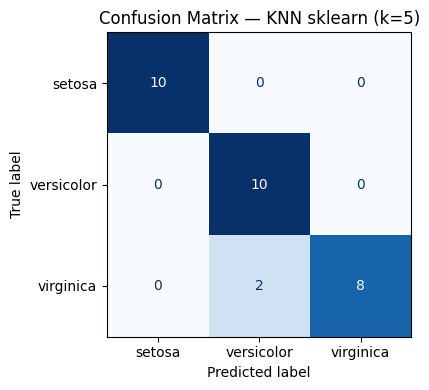

In [4]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — KNN sklearn (k=5)')
plt.tight_layout(); plt.show()

## 5. GridSearchCV — Optimal k + Metric + Weights

In [5]:
param_grid = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__metric':      ['euclidean', 'manhattan', 'chebyshev'],
    'knn__weights':     ['uniform', 'distance']
}

gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)

print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")
print(f"Test acc    : {accuracy_score(y_test, gs.best_estimator_.predict(X_test)):.4f}")

Best params : {'knn__metric': 'euclidean', 'knn__n_neighbors': 17, 'knn__weights': 'distance'}
Best CV acc : 0.9750
Test acc    : 0.9667


## 6. k Sweep — All Three Metrics

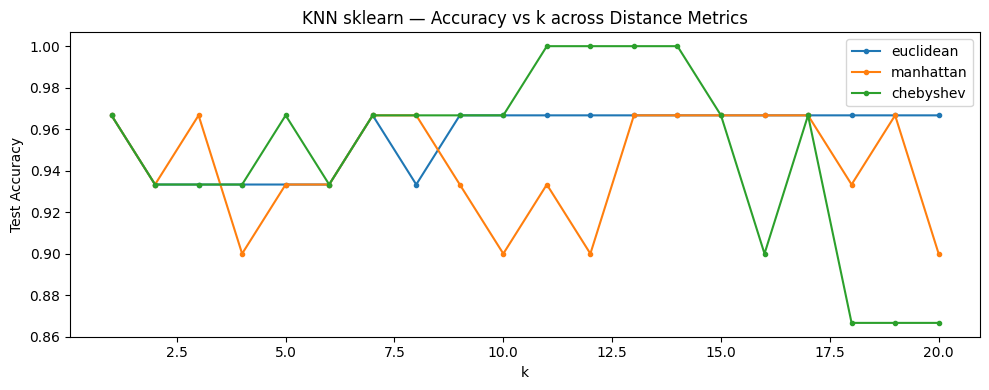

In [6]:
k_range = range(1, 21)
metrics_list = ['euclidean', 'manhattan', 'chebyshev']

fig, ax = plt.subplots(figsize=(10, 4))
for metric in metrics_list:
    accs = []
    for k in k_range:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=k, metric=metric))])
        pipe.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, pipe.predict(X_test)))
    ax.plot(k_range, accs, marker='o', markersize=3, label=metric)

ax.set_xlabel('k'); ax.set_ylabel('Test Accuracy')
ax.set_title('KNN sklearn — Accuracy vs k across Distance Metrics')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Uniform vs Distance Weighting

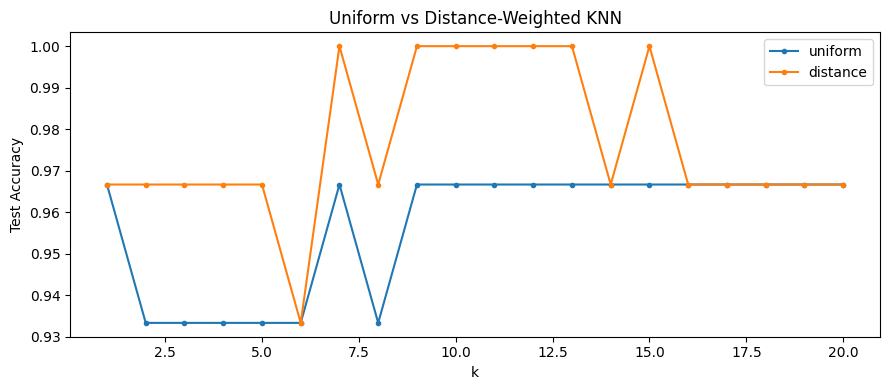

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for weights in ['uniform', 'distance']:
    accs = []
    for k in k_range:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=k, weights=weights))])
        pipe.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, pipe.predict(X_test)))
    ax.plot(k_range, accs, marker='o', markersize=3, label=weights)

ax.set_xlabel('k'); ax.set_ylabel('Test Accuracy')
ax.set_title('Uniform vs Distance-Weighted KNN')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Decision Boundary (Petal Length × Petal Width)

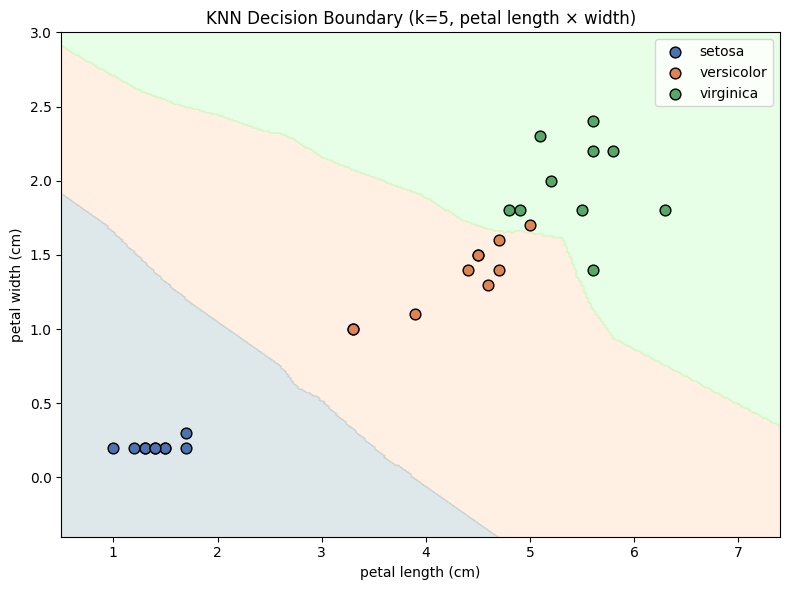

In [8]:
feat_idx = [2, 3]
X2_train = X_train[:, feat_idx]
X2_test  = X_test[:, feat_idx]

pipe2 = Pipeline([('sc', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe2.fit(X2_train, y_train)

x_min, x_max = X[:, feat_idx[0]].min()-0.5, X[:, feat_idx[0]].max()+0.5
y_min, y_max = X[:, feat_idx[1]].min()-0.5, X[:, feat_idx[1]].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = pipe2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

colors_bg = ['#AEC6CF', '#FFDAB9', '#C3FFC3']
colors_pt = ['#4C72B0', '#DD8452', '#55A868']
cmap_bg   = plt.matplotlib.colors.ListedColormap(colors_bg)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
for cls, col, name in zip([0,1,2], colors_pt, class_names):
    mask = y_test == cls
    ax.scatter(X2_test[mask,0], X2_test[mask,1], color=col, label=name, edgecolors='k', s=60)
ax.set_xlabel(features[feat_idx[0]]); ax.set_ylabel(features[feat_idx[1]])
ax.set_title('KNN Decision Boundary (k=5, petal length × width)')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Cross-Validation with Best Pipeline

In [9]:
best_pipe = gs.best_estimator_
cv_scores = cross_val_score(best_pipe, X, y, cv=10, scoring='accuracy')
print(f"10-fold CV — Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")
print(f"Scores: {cv_scores.round(4).tolist()}")

10-fold CV — Mean: 0.9600  Std: 0.0442
Scores: [1.0, 0.9333, 1.0, 0.9333, 0.9333, 0.9333, 0.8667, 1.0, 1.0, 1.0]


## 10. Save Model to `../Models/`

In [10]:
save_path = '../Models/knn_sklearn.joblib'
joblib.dump(pipeline, save_path)   # saves the k=5 euclidean uniform pipeline

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")
print(f"Best GridSearch pipeline also available at: gs.best_estimator_")

Saved → ../Models/knn_sklearn.joblib  (11.6 KB)
Best GridSearch pipeline also available at: gs.best_estimator_
